## Pandas

### Введение: создание и строение матриц

Пусть у нас есть какие-то данные табличного духа

In [1]:
data = [[ 0.990360, -1.131429, -1.065981,  0.855488],
        [ 0.493665,  0.589660, -0.432106, -0.240378],
        [-0.807992, -1.794176, -1.210304,  0.201295],
        [-0.270479, -1.121976,  0.459273, -0.178025],
        [ 0.188286, -0.931686,  1.959219,  0.387350],
        [ 2.252443,  0.848532,  0.925256,  1.014754]]

Создадим из них DataFrame (таблицу), дав колонкам имена

In [2]:
import pandas as pd
df = pd.DataFrame(data, columns=list('ABCD'))
print(df)

          A         B         C         D
0  0.990360 -1.131429 -1.065981  0.855488
1  0.493665  0.589660 -0.432106 -0.240378
2 -0.807992 -1.794176 -1.210304  0.201295
3 -0.270479 -1.121976  0.459273 -0.178025
4  0.188286 -0.931686  1.959219  0.387350
5  2.252443  0.848532  0.925256  1.014754


In [3]:
df

,A,B,C,D
0,0.990360,-1.131429,-1.065981,0.855488
1,0.493665,0.589660,-0.432106,-0.240378
2,-0.807992,-1.794176,-1.210304,0.201295
3,-0.270479,-1.121976,0.459273,-0.178025
4,0.188286,-0.931686,1.959219,0.387350
5,2.252443,0.848532,0.925256,1.014754


Мы можем задавать столбцы внутри данных через словарь:

In [4]:
data_dict = {'A': [1, 3, 5, 7],
        'B': [2, 4, 6, 8]}
df_dict = pd.DataFrame(data_dict)
df_dict

,A,B
0,1,2
1,3,4
2,5,6
3,7,8


Но если данные не однородны?

In [5]:
data_sep = {'A': 1.1,
        'B': pd.Timestamp('20200901'),
        'C': 111,
        'D': [42 * i  for i in range(4)],
        'E': 'foo'}
df_sep = pd.DataFrame(data_sep)
df_sep

,A,B,C,D,E
0,1.1,2020-09-01,111,0,foo
1,1.1,2020-09-01,111,42,foo
2,1.1,2020-09-01,111,84,foo
3,1.1,2020-09-01,111,126,foo


### Строение таблиц

#### Однородная таблица

In [6]:
df

,A,B,C,D
0,0.990360,-1.131429,-1.065981,0.855488
1,0.493665,0.589660,-0.432106,-0.240378
2,-0.807992,-1.794176,-1.210304,0.201295
3,-0.270479,-1.121976,0.459273,-0.178025
4,0.188286,-0.931686,1.959219,0.387350
5,2.252443,0.848532,0.925256,1.014754


In [7]:
df.index

RangeIndex(start=0, stop=6, step=1)

Прямое обращение к ячейке:

In [8]:
df.loc[0,'A']

np.float64(0.99036)

#### Неоднородная таблица

In [9]:
df_sep.dtypes

A          float64
B    datetime64[s]
C            int64
D            int64
E           object
dtype: object

In [10]:
df_sep.index

RangeIndex(start=0, stop=4, step=1)

In [11]:
df_sep.columns

Index(['A', 'B', 'C', 'D', 'E'], dtype='object')

#### Нестандартный индекс

In [12]:
dates = pd.date_range('20200101', periods=6)
df2 = pd.DataFrame(data, index=dates, columns=list('ABCD'))
df2

,A,B,C,D
2020-01-01,0.990360,-1.131429,-1.065981,0.855488
2020-01-02,0.493665,0.589660,-0.432106,-0.240378
2020-01-03,-0.807992,-1.794176,-1.210304,0.201295
2020-01-04,-0.270479,-1.121976,0.459273,-0.178025
2020-01-05,0.188286,-0.931686,1.959219,0.387350
2020-01-06,2.252443,0.848532,0.925256,1.014754


In [13]:
df2.index

DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-04',
               '2020-01-05', '2020-01-06'],
              dtype='datetime64[ns]', freq='D')

In [14]:
df2.loc['20200101','A']

np.float64(0.99036)

### Доступ

#### Выборки средствами .loc

Возьмём неоднородную таблицу:

In [15]:
df_sep

,A,B,C,D,E
0,1.1,2020-09-01,111,0,foo
1,1.1,2020-09-01,111,42,foo
2,1.1,2020-09-01,111,84,foo
3,1.1,2020-09-01,111,126,foo


При обращении через .loc используются ключи. Можно использовать отдельные значения, списки, диапазоны.

In [16]:
df_sep.loc[1:2]

,A,B,C,D,E
1,1.1,2020-09-01,111,42,foo
2,1.1,2020-09-01,111,84,foo


Запрос только к столбцу

In [17]:
df_sep.loc[:,'D']

0      0
1     42
2     84
3    126
Name: D, dtype: int64

Заданная пара строк, избранные столбцы

In [18]:
df_sep.loc[1:2,['A', 'D']]

,A,D
1,1.1,42
2,1.1,84


Обращение к ячейке:

In [19]:
df_sep.loc[1,'A']

np.float64(1.1)

#### Выборка через at

Может работать только со скалярами, но быстрее

In [20]:
df_sep.at[1,'A']

np.float64(1.1)

#### Выборки средствами .iloc

При обращении через .iloc используются номера строк и столбцов, а не имена.

In [21]:
df_sep.iloc[[0,3],[0,3]]

,A,D
0,1.1,0
3,1.1,126


In [22]:
df_sep.iloc[1,3]

np.int64(42)

In [23]:
df_sep.iat[1,3]

np.int64(42)

#### И "обычный" доступ наподобие массива (под капотом тот же **loc**)

Первым индексом можно взять столбец

In [24]:
df_sep['D']

0      0
1     42
2     84
3    126
Name: D, dtype: int64

Или несколько столбцов:

In [25]:
df_sep[['A','D']]

,A,D
0,1.1,0
1,1.1,42
2,1.1,84
3,1.1,126


Или диапазон строк

In [26]:
df_sep[0:2]

,A,B,C,D,E
0,1.1,2020-09-01,111,0,foo
1,1.1,2020-09-01,111,42,foo


### Модификация

In [27]:
df_sep.loc[0,'D'] = -42
df_sep

,A,B,C,D,E
0,1.1,2020-09-01,111,-42,foo
1,1.1,2020-09-01,111,42,foo
2,1.1,2020-09-01,111,84,foo
3,1.1,2020-09-01,111,126,foo


Или приравниваем весь range

In [28]:
df_sep.loc[:,'D'] = [i for i in range(4)]
df_sep

,A,B,C,D,E
0,1.1,2020-09-01,111,0,foo
1,1.1,2020-09-01,111,1,foo
2,1.1,2020-09-01,111,2,foo
3,1.1,2020-09-01,111,3,foo


### Теперь посмотрим булевы индексы

In [29]:
df_sep.loc[:,'D'] = [i * 42 for i in range(4)]

Мы можем создать булев столбец, соответствующий какому-то условию, используя столбец DataFrame

In [30]:
df_sep['D'] > 42

0    False
1    False
2     True
3     True
Name: D, dtype: bool

И использовать его в качестве индекса

In [31]:
df_sep[df_sep['D'] > 0]

,A,B,C,D,E
1,1.1,2020-09-01,111,42,foo
2,1.1,2020-09-01,111,84,foo
3,1.1,2020-09-01,111,126,foo


In [32]:
df_sep[df_sep['D'] > 42]

,A,B,C,D,E
2,1.1,2020-09-01,111,84,foo
3,1.1,2020-09-01,111,126,foo


В том числе и для модификации - .loc обращается к реальным данным

In [33]:
df_sep.loc[df_sep['D'] > 42,'D'] = 0
df_sep

,A,B,C,D,E
0,1.1,2020-09-01,111,0,foo
1,1.1,2020-09-01,111,42,foo
2,1.1,2020-09-01,111,0,foo
3,1.1,2020-09-01,111,0,foo


### Сортировка данных

In [34]:
df_sep = pd.DataFrame({'A': 1.1,
        'B': pd.Timestamp('20200901'),
        'C': [i for i in range(4)],
        'D': [42 * (i-1)**2  for i in range(4)],
        'E': 'foo'
})
df_sep

,A,B,C,D,E
0,1.1,2020-09-01,0,42,foo
1,1.1,2020-09-01,1,0,foo
2,1.1,2020-09-01,2,42,foo
3,1.1,2020-09-01,3,168,foo


In [35]:
df_sep.sort_values(by='D')

,A,B,C,D,E
1,1.1,2020-09-01,1,0,foo
0,1.1,2020-09-01,0,42,foo
2,1.1,2020-09-01,2,42,foo
3,1.1,2020-09-01,3,168,foo


Можем менять порядок

In [36]:
df_sep.sort_values(by='D', ascending=False)

,A,B,C,D,E
3,1.1,2020-09-01,3,168,foo
0,1.1,2020-09-01,0,42,foo
2,1.1,2020-09-01,2,42,foo
1,1.1,2020-09-01,1,0,foo


Или сортировать по нескольким столбцам:

In [37]:
df_sep.sort_values(by=['D', 'C'], ascending=False)

,A,B,C,D,E
3,1.1,2020-09-01,3,168,foo
2,1.1,2020-09-01,2,42,foo
0,1.1,2020-09-01,0,42,foo
1,1.1,2020-09-01,1,0,foo


Или через цепочки

In [38]:
df_sep.loc[df_sep['D'] >= 42].sort_values(by='D', ascending=True)

,A,B,C,D,E
0,1.1,2020-09-01,0,42,foo
2,1.1,2020-09-01,2,42,foo
3,1.1,2020-09-01,3,168,foo


Но функции не меняют DataFrame

In [39]:
df_sep

,A,B,C,D,E
0,1.1,2020-09-01,0,42,foo
1,1.1,2020-09-01,1,0,foo
2,1.1,2020-09-01,2,42,foo
3,1.1,2020-09-01,3,168,foo


Если нужно изменить, используем inplace

In [40]:
df_sep.sort_values(by=['D', 'C'], ascending=False, inplace=True)
df_sep

,A,B,C,D,E
3,1.1,2020-09-01,3,168,foo
2,1.1,2020-09-01,2,42,foo
0,1.1,2020-09-01,0,42,foo
1,1.1,2020-09-01,1,0,foo


### Работа с пропусками

In [41]:
df_sep.loc[1:2, 'F'] = 'test'
df_sep

,A,B,C,D,E,F
3,1.1,2020-09-01,3,168,foo,NaN
2,1.1,2020-09-01,2,42,foo,NaN
0,1.1,2020-09-01,0,42,foo,NaN
1,1.1,2020-09-01,1,0,foo,NaN


In [42]:
df_sep.fillna(value='')

,A,B,C,D,E,F
3,1.1,2020-09-01,3,168,foo,
2,1.1,2020-09-01,2,42,foo,
0,1.1,2020-09-01,0,42,foo,
1,1.1,2020-09-01,1,0,foo,


### Статистика по таблице

In [43]:
data = {'A': 1.1,
        'B': pd.Timestamp('20200901'),
        'C': 111,
        'D': [i ** 2  for i in range(4)],
        'E': 'foo'}

df_sep = pd.DataFrame(data)
df_sep

,A,B,C,D,E
0,1.1,2020-09-01,111,0,foo
1,1.1,2020-09-01,111,1,foo
2,1.1,2020-09-01,111,4,foo
3,1.1,2020-09-01,111,9,foo


In [44]:
target = df_sep.loc[df_sep['D'] > 0, 'D']
target

1    1
2    4
3    9
Name: D, dtype: int64

Мы можем пользоваться стандартными функциями:

In [45]:
print(target.min())
print(target.max())
print(target.mean())
print(target.median())

1
9
4.666666666666667
4.0


### Дополнительно: арифметика со столбцами

Выражения со значениями столбцов в pandas вычисляются эффективно:

In [46]:
df_sep

,A,B,C,D,E
0,1.1,2020-09-01,111,0,foo
1,1.1,2020-09-01,111,1,foo
2,1.1,2020-09-01,111,4,foo
3,1.1,2020-09-01,111,9,foo


In [47]:
df_sep['D'] ** 2 + 1

0     1
1     2
2    17
3    82
Name: D, dtype: int64

Или для данных по индексу

In [48]:
df_sep.loc[df_sep['D'] > 0, 'D'] ** 2 + 1

1     2
2    17
3    82
Name: D, dtype: int64

Или нам нужно количество **True** или **False** значений в столбце:

In [49]:
sum(df_sep['D'] > 0)

3

### Apply

Apply - плохая идея, т.к. плохо для производительности

In [50]:
df_sep.loc[:,['A', 'C', 'D']].apply(lambda x: x**2)

,A,C,D
0,1.21,12321,0
1,1.21,12321,1
2,1.21,12321,16
3,1.21,12321,81


### Функции, похожие на операции БД (groupby, join)

#### join

In [51]:
left = pd.DataFrame({'key': ['foo', 'bar'], 'lval': [1, 2]})
right = pd.DataFrame({'key': ['foo', 'bar'], 'rval': [4, 5]})

print(left)
print("=======")
print(right)

   key  lval
0  foo     1
1  bar     2
   key  rval
0  foo     4
1  bar     5


In [52]:
pd.merge(left, right, on='key')

,key,lval,rval
0,foo,1,4
1,bar,2,5


Если списки ключей не совпадают

In [53]:
right2 = pd.DataFrame({'key': ['foo', 'baz'], 'rval': [4, 5]})
right2


,key,rval
0,foo,4
1,baz,5


In [54]:
pd.merge(left, right2, on='key')

,key,lval,rval
0,foo,1,4


Если ключи дублируются:

In [55]:
left3 = pd.DataFrame({'key': ['foo', 'foo'], 'lval': [1, 2]})
right3 = pd.DataFrame({'key': ['foo', 'foo'], 'rval': [4, 5]})

print(left3)
print("=====")
print(right3)
pd.merge(left3, right3, on='key')

   key  lval
0  foo     1
1  foo     2
=====
   key  rval
0  foo     4
1  foo     5


,key,lval,rval
0,foo,1,4
1,foo,1,5
2,foo,2,4
3,foo,2,5


Если имена столбцов не совпадают, можем воспользоваться `left_on`, `right_on`:

In [56]:
left = pd.DataFrame({'key_left': ['foo', 'bar'], 'lval': [1, 2]})
right = pd.DataFrame({'key_right': ['foo', 'bar'], 'rval': [4, 5]})

print(left)
print("=======")
print(right)
pd.merge(left, right, left_on='key_left', right_on="key_right")

  key_left  lval
0      foo     1
1      bar     2
  key_right  rval
0       foo     4
1       bar     5


,key_left,lval,key_right,rval
0,foo,1,foo,4
1,bar,2,bar,5


#### groupby

In [57]:
df = pd.DataFrame({'A': ['foo', 'bar', 'foo', 'bar', 'foo', 'bar', 'foo', 'foo'],
                   'B': ['one', 'one', 'two', 'three', 'two', 'two', 'one', 'three'],
                   'C': [i for i in range(8)],
                   'D': [i**2 for i in range(8)]})
df

,A,B,C,D
0,foo,one,0,0
1,bar,one,1,1
2,foo,two,2,4
3,bar,three,3,9
4,foo,two,4,16
5,bar,two,5,25
6,foo,one,6,36
7,foo,three,7,49


Мы можем аггрегировать суммы (среднее, медиану и т.д.)

In [58]:
df.groupby('A').sum()

,B,C,D
A,,,
bar,onethreetwo,9,35
foo,onetwotwoonethree,19,105


Или количества значений

In [59]:
df.groupby('A').size()

A
bar    3
foo    5
dtype: int64

Или так:

In [60]:
df.groupby('A').count()

,B,C,D
A,,,
bar,3,3,3
foo,5,5,5


Причём сам **groupby** создаёт объект отдельного типа:

In [61]:
df.groupby('A')

#### Пример

Онлайн-заказы: рассмотрим таблицы, описывающие клиентов, продукты и заказы в интернет-магазине:

In [62]:
buyer = pd.DataFrame({"Buyer_name": ["Иван Иванов", "Пётр Петров", "Сергей Сидоров", "Кирилл Кузнецов"],
                      "Buyer_id": ["E001", "E003", "E007", "E008"]})
product = pd.DataFrame({"Product_name": ["Стиральная машина", "Мультиварка", "Микроволновка"],
                        "Price": [40000, 4000, 5000],
                        "Product_id": ["P001", "P003", "P009"]})
purchase = pd.DataFrame({"Buyer_id":   ["E001", "E003", "E007", "E008", "E003", "E007", "E001", "E008"],
                         "Product_id": ["P001", "P003", "P009", "P001", "P003", "P009", "P001", "P003"]})
print(buyer)
print("============")
print(product)
print("============")
print(purchase)

        Buyer_name Buyer_id
0      Иван Иванов     E001
1      Пётр Петров     E003
2   Сергей Сидоров     E007
3  Кирилл Кузнецов     E008
        Product_name  Price Product_id
0  Стиральная машина  40000       P001
1        Мультиварка   4000       P003
2      Микроволновка   5000       P009
  Buyer_id Product_id
0     E001       P001
1     E003       P003
2     E007       P009
3     E008       P001
4     E003       P003
5     E007       P009
6     E001       P001
7     E008       P003


Сопоставим данные о ценах и покупках

In [63]:
purchase_prices = pd.merge(purchase, product, on="Product_id")[["Product_name", "Price"]]
purchase_prices

,Product_name,Price
0,Стиральная машина,40000
1,Мультиварка,4000
2,Микроволновка,5000
3,Стиральная машина,40000
4,Мультиварка,4000
5,Микроволновка,5000
6,Стиральная машина,40000
7,Мультиварка,4000


И получим общую стоимость для каждого продукта

In [64]:
print(purchase_prices.groupby("Product_name").sum())

                    Price
Product_name             
Микроволновка       10000
Мультиварка         12000
Стиральная машина  120000


Или мы можем подсчитать через количества покупок каждого продукта:

In [65]:
purchase_counts = purchase[["Product_id"]].groupby("Product_id").size()
print("Куплено:")
print(purchase_counts)
product_idx = product.set_index("Product_id")
product_idx["Total"] = product_idx["Price"]*purchase_counts
product_idx

Куплено:
Product_id
P001    3
P003    3
P009    2
dtype: int64


,Product_name,Price,Total
Product_id,,,
P001,Стиральная машина,40000,120000
P003,Мультиварка,4000,12000
P009,Микроволновка,5000,10000


Теперь найдём суммарную стоимость покупок пользователя:

In [66]:
buyer_prices = pd.merge(purchase, product, on="Product_id")[["Buyer_id", "Price"]]
buyer_prices = buyer_prices.groupby("Buyer_id").sum()
buyer_prices

,Price
Buyer_id,
E001,80000
E003,8000
E007,10000
E008,44000


И сопоставим с именами:

In [67]:
buyer["Spent"] = buyer["Buyer_id"].map(buyer_prices["Price"])
buyer

,Buyer_name,Buyer_id,Spent
0,Иван Иванов,E001,80000
1,Пётр Петров,E003,8000
2,Сергей Сидоров,E007,10000
3,Кирилл Кузнецов,E008,44000


### Графики

Мы можем строить графики по объектам pandas напрямую:

                     B   C    D
A                              
bar        onethreetwo   9   35
foo  onetwotwoonethree  19  105


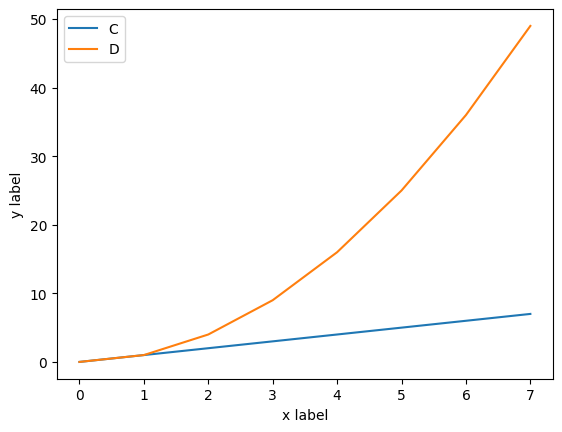

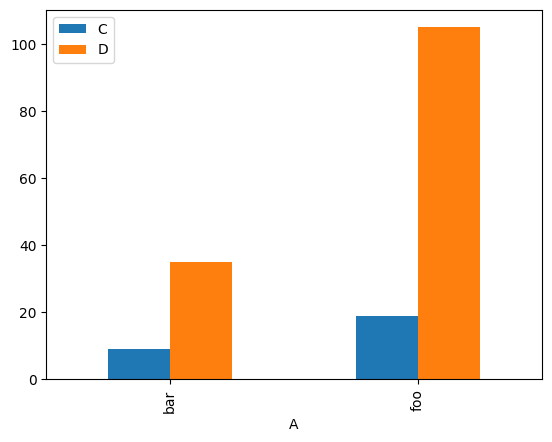

In [68]:
import matplotlib.pyplot as plt
ax = df.plot()
ax.set_xlabel('x label')
ax.set_ylabel('y label')

aggr = df.groupby('A').sum()
print(aggr)

# И их тоже нарисовать
ax2 = aggr.plot(kind='bar')

plt.show()